In [1]:
%pip install pandas

Note: you may need to restart the kernel to use updated packages.


# Task
Perform data analysis, build a TensorFlow model for diabetic prediction, evaluate its performance, and explain its predictions using SHAP, starting by loading a "diabetics dataset".

## Load Diabetics Data

### Subtask:
Load the diabetics dataset into a pandas DataFrame. This will be the starting point for our analysis and model building.


**Reasoning**:
The first instruction is to import the pandas library. This is a prerequisite for loading data into a DataFrame.



In [4]:
import pandas as pd
print("pandas imported as pd.")

pandas imported as pd.


**Reasoning**:
The next step is to load the 'diabetics dataset' from the 'diabetics.csv' file into a pandas DataFrame named 'df' and then display its first 5 rows to verify the load.



In [5]:
df = pd.read_csv('diabetes.csv')
print("Diabetics dataset loaded into DataFrame 'df'.")
df.head()
df.columns

Diabetics dataset loaded into DataFrame 'df'.


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

**Reasoning**:
The 'diabetics.csv' file was not found, causing a FileNotFoundError. To address this, a common diabetes dataset will be downloaded from a public URL and saved as 'diabetics.csv' to match the requested filename, and then loaded into a DataFrame.



In [6]:
# !wget -O diabetics.csv https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv
# df = pd.read_csv('diabetics.csv')
# print("Diabetics dataset loaded into DataFrame 'df'.")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Univariate Analysis

### Subtask:
Perform univariate analysis on the dataset. This includes descriptive statistics, checking for missing values, and visualizing the distribution of individual features using histograms or box plots. Ensure to provide clear legends for all visualizations.


**Reasoning**:
The first instruction is to display descriptive statistics for the DataFrame `df`. This will provide a summary of the numerical features, including count, mean, standard deviation, min, max, and quartiles, which is a key part of univariate analysis.



In [5]:
print("Descriptive statistics for the DataFrame 'df':")
df.describe()

Descriptive statistics for the DataFrame 'df':


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


**Reasoning**:
The next instruction is to check for missing values in the DataFrame `df` and display the count of missing values for each column. This is important for understanding data completeness.



In [6]:
print("Missing values in each column of the DataFrame 'df':")
df.isnull().sum()

Missing values in each column of the DataFrame 'df':


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

**Reasoning**:
The next step is to identify the numerical columns in the DataFrame `df`. This is necessary before creating visualizations like histograms and box plots for these features.



In [7]:
print("Data types of each column in the DataFrame 'df':")
print(df.dtypes)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"\nIdentified numerical columns: {numerical_cols}")

Data types of each column in the DataFrame 'df':
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Identified numerical columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


**Reasoning**:
Now that the numerical columns have been identified, the next step is to generate histograms for each of these columns. This will help visualize the distribution of individual features as part of the univariate analysis. I will use `matplotlib.pyplot` and `seaborn` for plotting, arranging the plots in subplots for better readability.



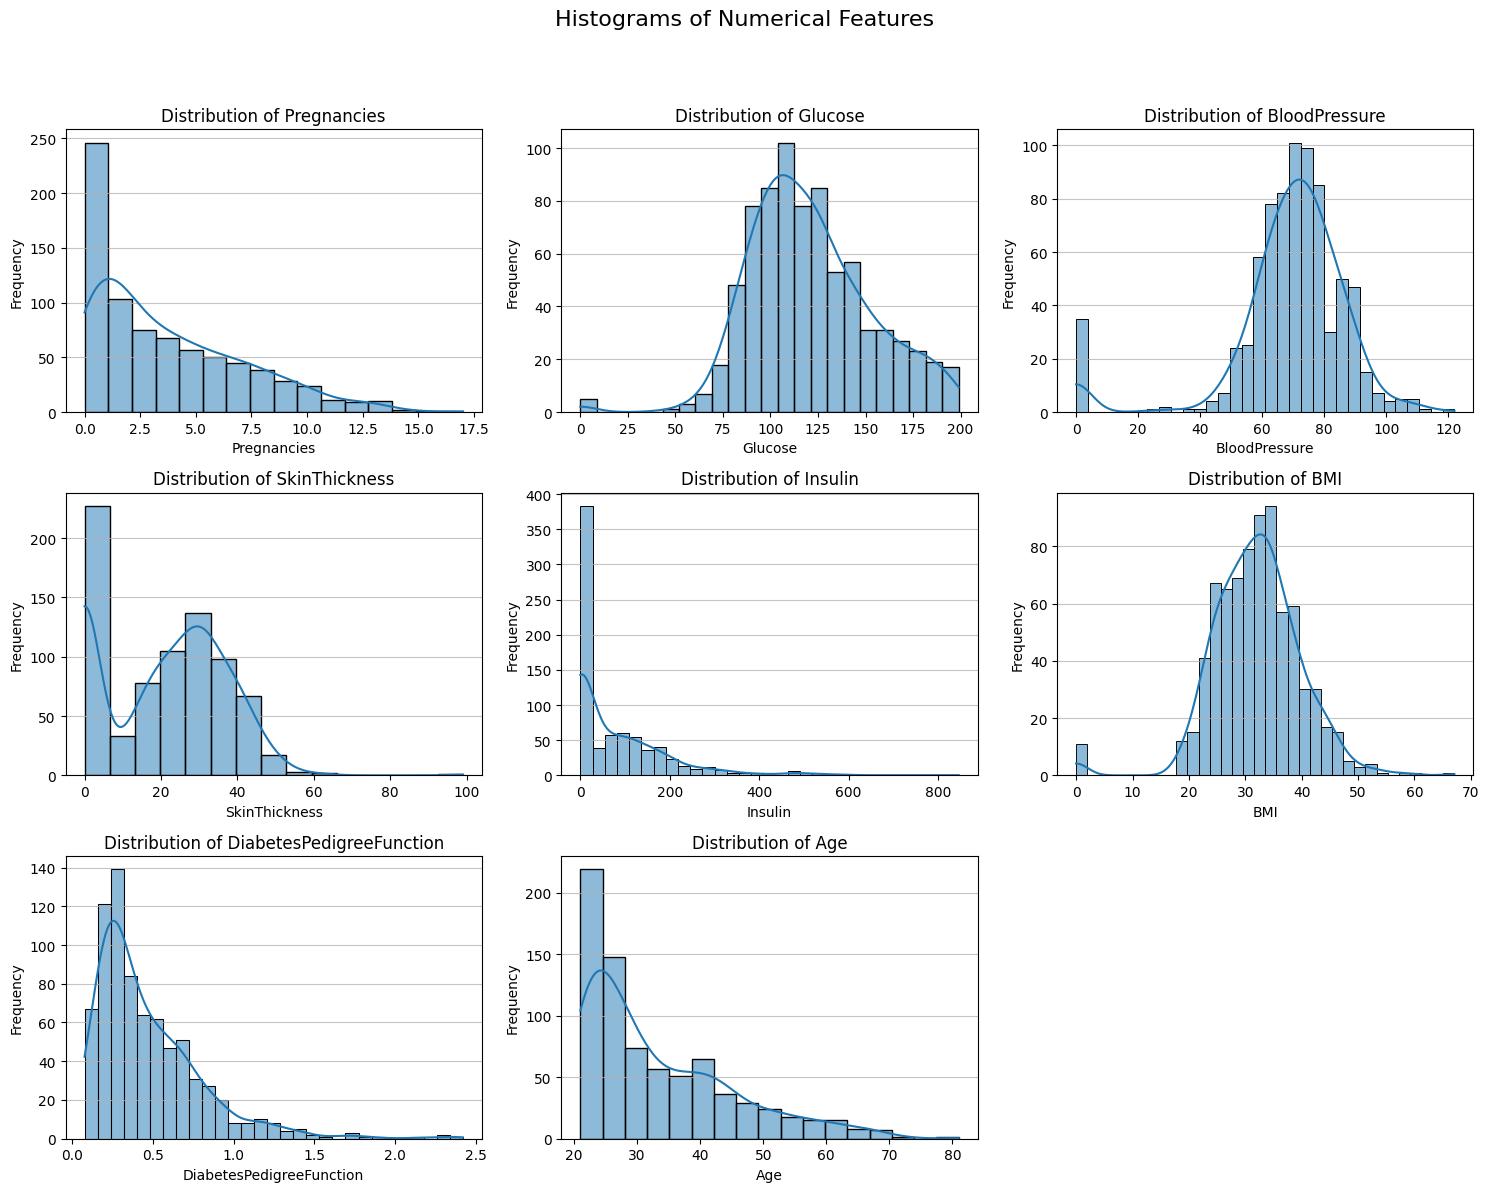

Histograms for numerical features displayed.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude 'Outcome' from histograms as it's a target variable and often better visualized differently (e.g., count plot)
histogram_cols = [col for col in numerical_cols if col != 'Outcome']

# Determine number of rows and columns for subplots
num_features = len(histogram_cols)
num_cols = 3 # Number of columns for the subplot grid
num_rows = (num_features + num_cols - 1) // num_cols # Calculate rows needed

plt.figure(figsize=(num_cols * 5, num_rows * 4))
plt.suptitle('Histograms of Numerical Features', y=1.02, fontsize=16)

for i, col in enumerate(histogram_cols):
    plt.subplot(num_rows, num_cols, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()
print("Histograms for numerical features displayed.")

**Reasoning**:
The next instruction is to generate box plots for each numerical column to visualize their distribution and identify outliers. I will continue to use `matplotlib.pyplot` and `seaborn` for plotting, arranging the plots in subplots for better readability. Similar to histograms, 'Outcome' will be excluded as it is a target variable.



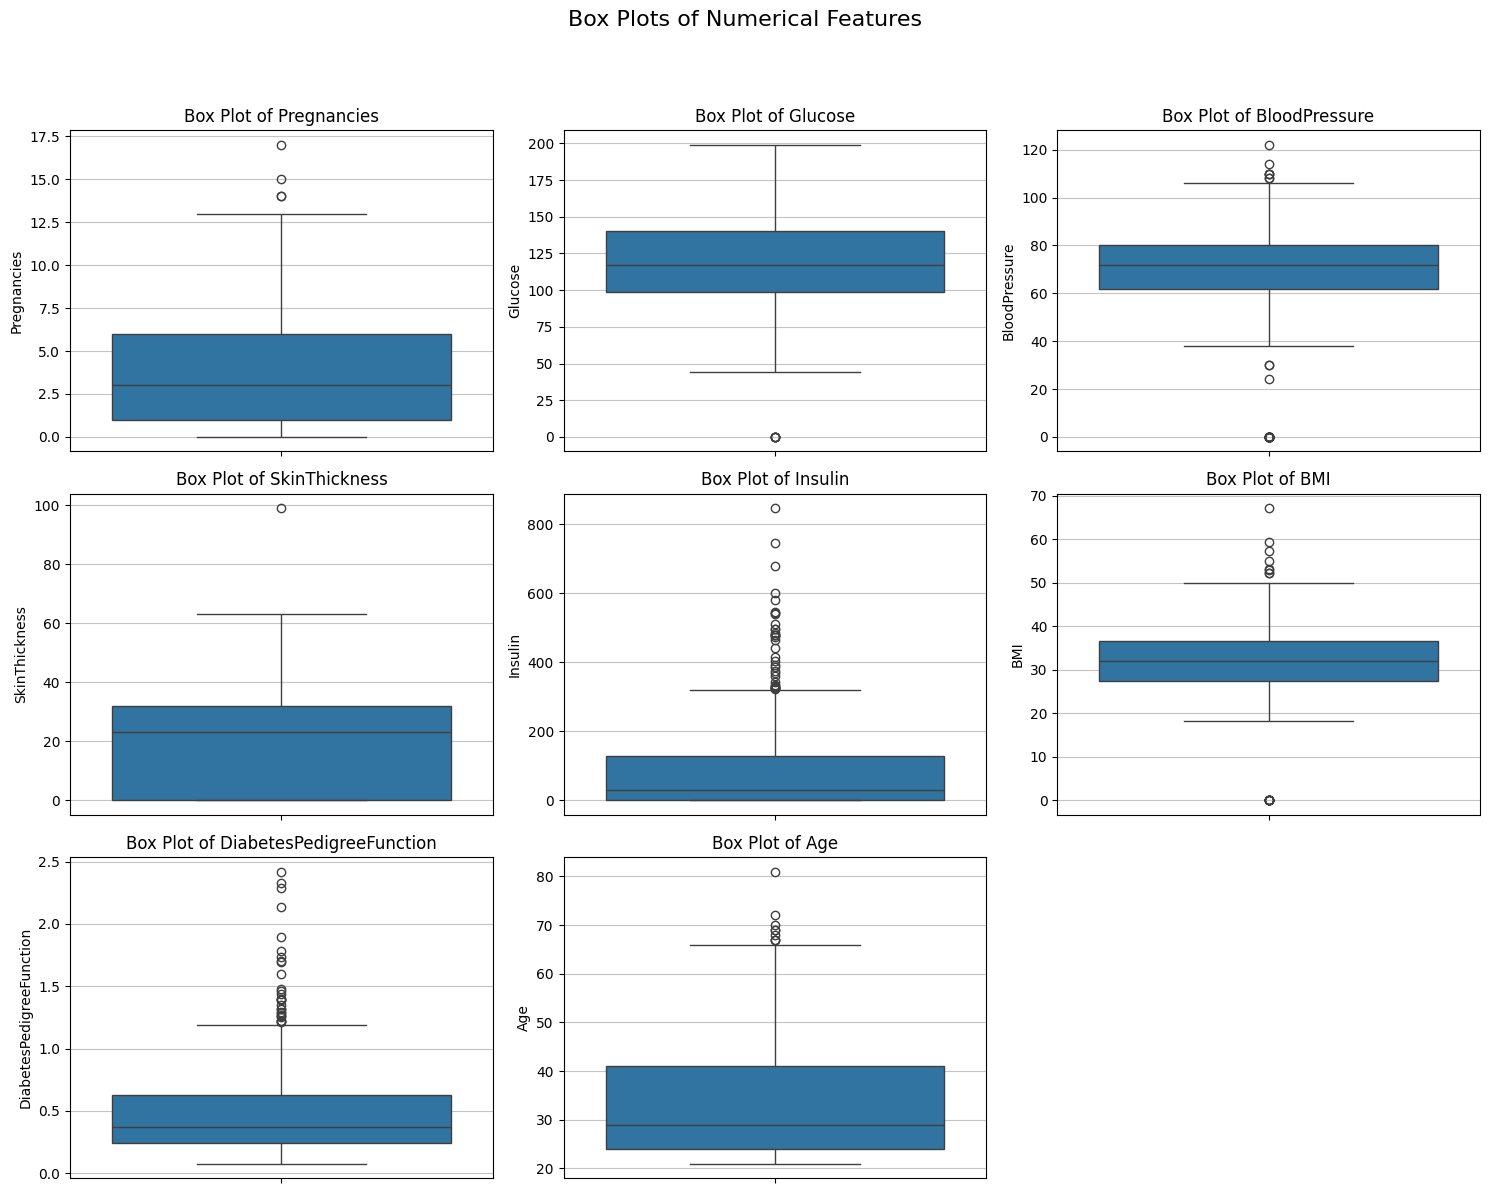

Box plots for numerical features displayed.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Exclude 'Outcome' from box plots as it's a target variable
boxplot_cols = [col for col in numerical_cols if col != 'Outcome']

# Determine number of rows and columns for subplots
num_features_bp = len(boxplot_cols)
num_cols_bp = 3 # Number of columns for the subplot grid
num_rows_bp = (num_features_bp + num_cols_bp - 1) // num_cols_bp # Calculate rows needed

plt.figure(figsize=(num_cols_bp * 5, num_rows_bp * 4))
plt.suptitle('Box Plots of Numerical Features', y=1.02, fontsize=16)

for i, col in enumerate(boxplot_cols):
    plt.subplot(num_rows_bp, num_cols_bp, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()
print("Box plots for numerical features displayed.")

## Bivariate Analysis

### Subtask:
Conduct bivariate analysis to understand relationships between pairs of features and between features and the target variable. This might involve scatter plots, pair plots, or group-wise comparisons. Ensure to provide clear legends for all visualizations.


**Reasoning**:
The next instruction is to create a series of box plots to visualize the distribution of each numerical feature (excluding 'Outcome') with respect to the 'Outcome' variable, which helps in understanding feature-target relationships. I will use `matplotlib.pyplot` and `seaborn` for plotting, arranging the plots in subplots for better readability.



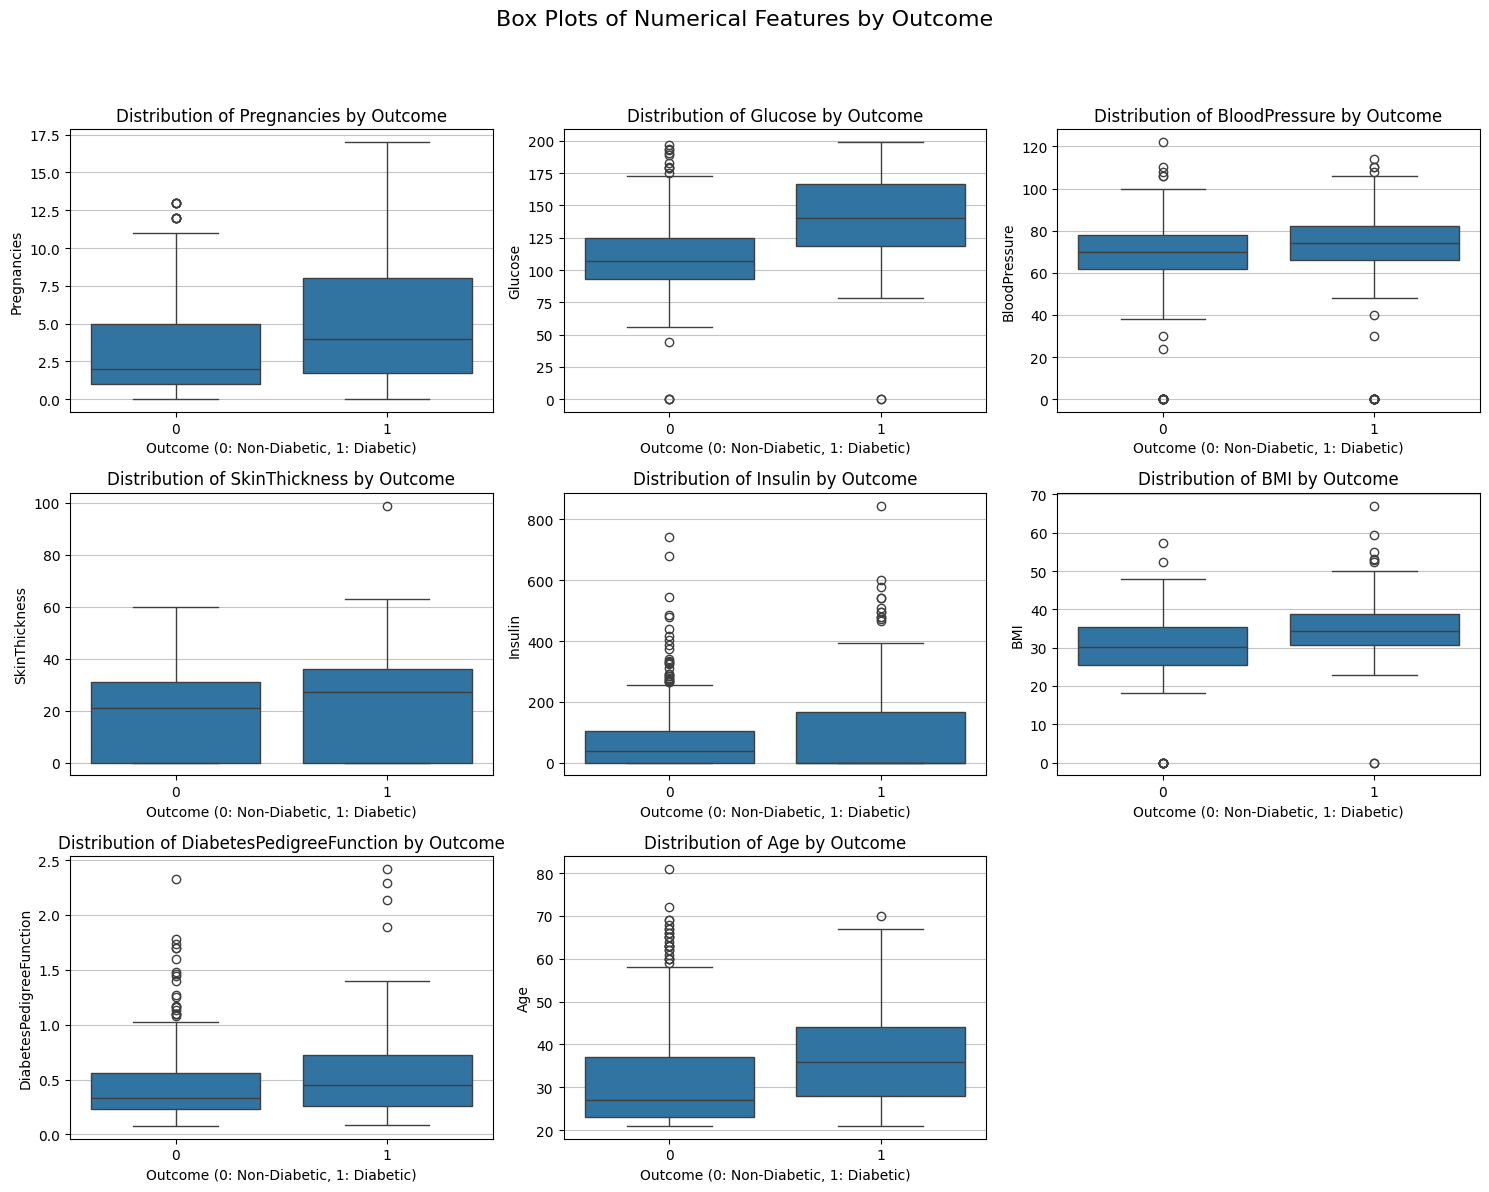

Box plots for numerical features against 'Outcome' displayed.


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# 'numerical_cols' contains all numerical columns including 'Outcome'
# 'boxplot_cols' already excludes 'Outcome' based on previous steps

# Determine number of rows and columns for subplots
num_features_biv = len(boxplot_cols)
num_cols_biv = 3 # Number of columns for the subplot grid
num_rows_biv = (num_features_biv + num_cols_biv - 1) // num_cols_biv # Calculate rows needed

plt.figure(figsize=(num_cols_biv * 5, num_rows_biv * 4))
plt.suptitle('Box Plots of Numerical Features by Outcome', y=1.02, fontsize=16)

for i, col in enumerate(boxplot_cols):
    plt.subplot(num_rows_biv, num_cols_biv, i + 1)
    sns.boxplot(x='Outcome', y=col, data=df)
    plt.title(f'Distribution of {col} by Outcome')
    plt.xlabel('Outcome (0: Non-Diabetic, 1: Diabetic)')
    plt.ylabel(col)
    plt.grid(axis='y', alpha=0.75)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()
print("Box plots for numerical features against 'Outcome' displayed.")

**Reasoning**:
The next instruction is to generate a pair plot for a subset of numerical features, including the 'Outcome' variable, to visualize pairwise relationships and distributions. This will help understand the interactions between different features and their relationship with the target variable, which is a key part of bivariate analysis.



<Figure size 1000x1000 with 0 Axes>

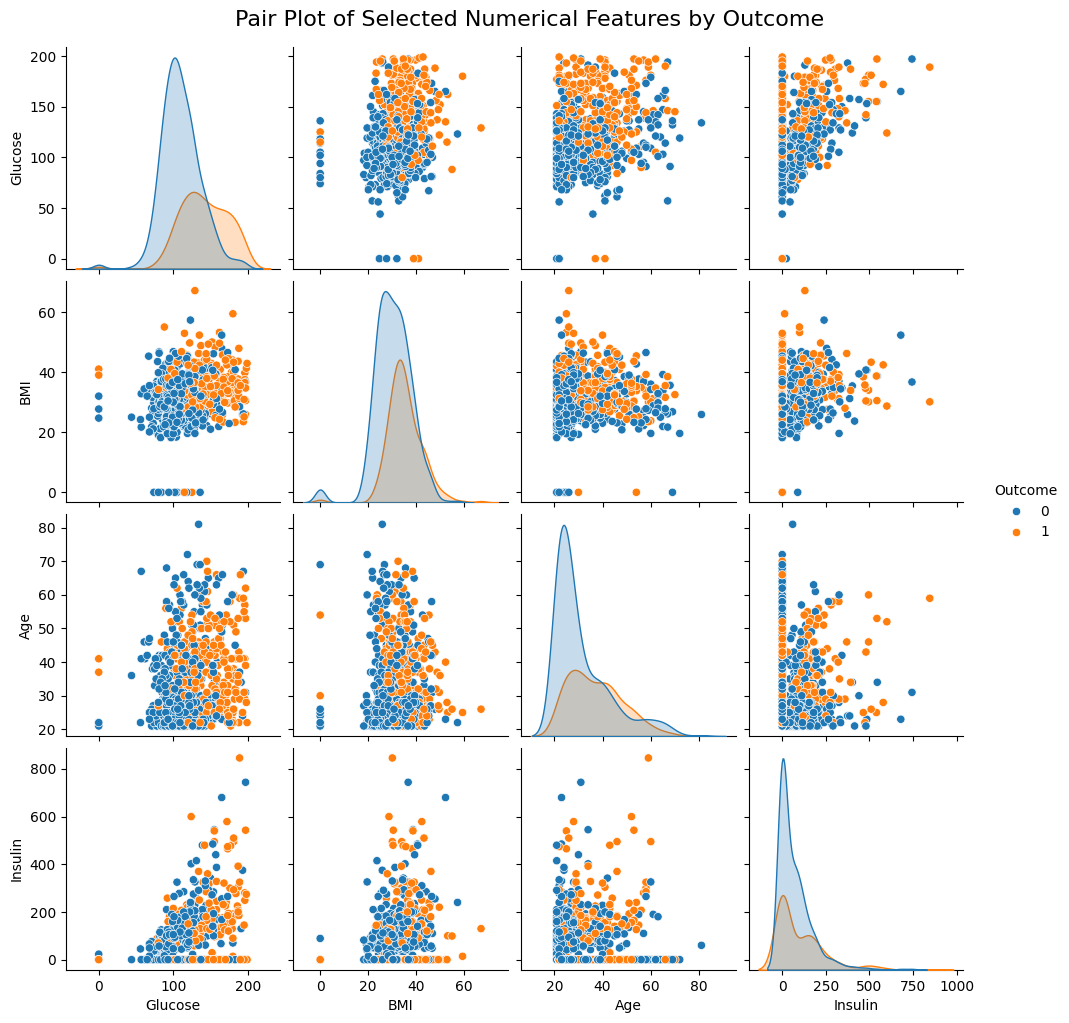

Pair plot for selected numerical features displayed.


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select a subset of numerical features for the pair plot, including the 'Outcome'
# Choosing a few key features to keep the plot manageable and informative
pairplot_features = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome'] # Selected key features

# Create the pair plot
plt.figure(figsize=(10, 10))
sns.pairplot(df[pairplot_features], hue='Outcome', diag_kind='kde')
plt.suptitle('Pair Plot of Selected Numerical Features by Outcome', y=1.02, fontsize=16) # Adjust suptitle position
plt.show()
print("Pair plot for selected numerical features displayed.")

## Create Correlation Heatmap

### Subtask:
Generate a heatmap to visualize the correlation matrix of the numerical features in the dataset. This will help identify highly correlated features. Ensure to provide a clear legend for the heatmap.


**Reasoning**:
The next instruction is to calculate the correlation matrix of the numerical features in the DataFrame `df` and then visualize it using a heatmap. This is a key step in bivariate analysis to understand relationships between all pairs of numerical features.



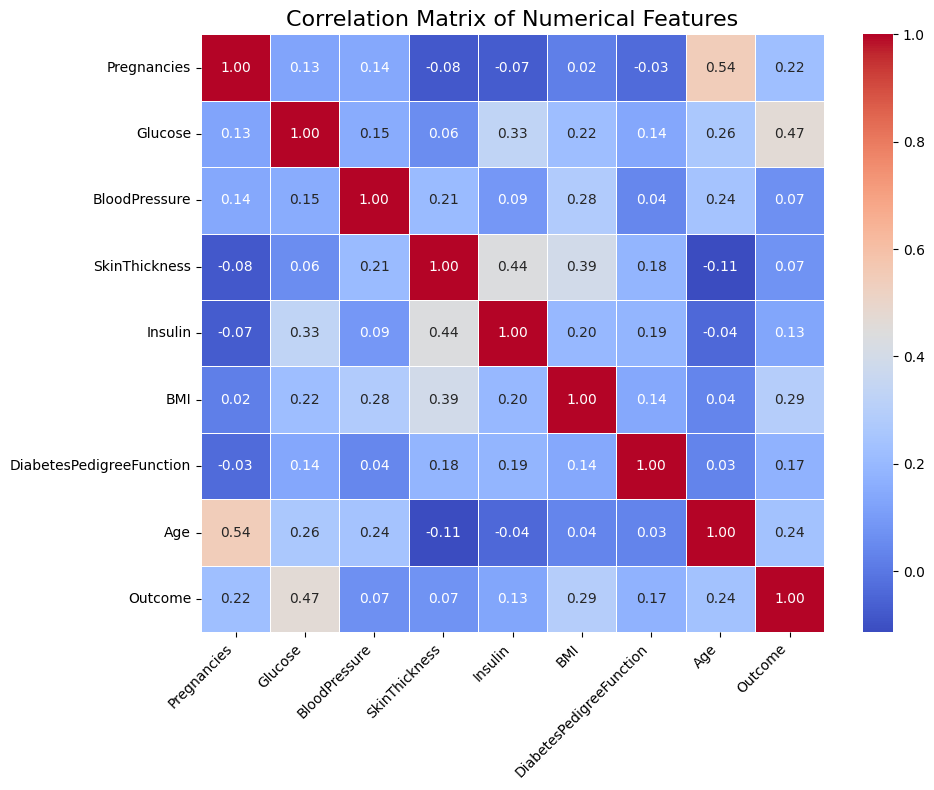

Correlation heatmap displayed.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
# Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
print("Correlation heatmap displayed.")

## Prepare Data for TensorFlow

### Subtask:
Preprocess the data for the TensorFlow model, which includes identifying features and target, handling zero values in specific columns, scaling numerical features, and splitting the data into training and testing sets.


**Reasoning**:
The first instruction is to separate the DataFrame `df` into features (X) and the target variable (y). This is a fundamental step in preparing data for supervised learning models.



In [13]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print("Features (X) and Target (y) separated.")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Features (X) and Target (y) separated.
Shape of X: (768, 8)
Shape of y: (768,)


**Reasoning**:
The next instruction is to identify columns with physiologically implausible '0' values and replace them with `NaN`. This addresses potential data quality issues that can affect model performance.



In [14]:
cols_to_replace_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_to_replace_zero:
    X[col] = X[col].replace(0, pd.NA)

print("'0' values in physiologically implausible columns replaced with NaN in features (X).")
print("Number of NaN values after replacement:")
print(X[cols_to_replace_zero].isnull().sum())

'0' values in physiologically implausible columns replaced with NaN in features (X).
Number of NaN values after replacement:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


**Reasoning**:
The next instruction is to impute the `NaN` values in the identified columns using the mean of each respective column. This will handle the missing data created in the previous step and prepare the data for scaling.



In [15]:
for col in cols_to_replace_zero:
    X[col] = X[col].fillna(X[col].mean())

print("NaN values in physiologically implausible columns imputed with their respective means in features (X).")
print("Number of NaN values after imputation:")
print(X[cols_to_replace_zero].isnull().sum())

NaN values in physiologically implausible columns imputed with their respective means in features (X).
Number of NaN values after imputation:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_18968\3717205175.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[col] = X[col].fillna(X[col].mean())


**Reasoning**:
The next instruction is to import `StandardScaler` from `sklearn.preprocessing`, initialize it, fit it to the features (X), and then transform X to `X_scaled`. This is essential for normalizing the numerical features before training a machine learning model.



In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Numerical features scaled using StandardScaler.")
print(f"Shape of X_scaled: {X_scaled.shape}")

Numerical features scaled using StandardScaler.
Shape of X_scaled: (768, 8)


**Reasoning**:
The final instruction is to split the `X_scaled` features and the target variable (y) into training and testing sets using `train_test_split`. This is a crucial step for model evaluation and preventing overfitting. I will use a `test_size` of 0.2 and a `random_state` for reproducibility, as specified in the instructions.



In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Data split into training and testing sets.")
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Data split into training and testing sets.
Shape of X_train: (614, 8)
Shape of X_test: (154, 8)
Shape of y_train: (614,)
Shape of y_test: (154,)


## Build and Train TensorFlow Model

### Subtask:
Construct a suitable neural network model using TensorFlow. Compile the model with an appropriate optimizer, loss function, and metrics relevant to the type of prediction (e.g., accuracy, precision, recall for classification). Then, train the model using the prepared training data.


In [20]:
# !pip install --upgrade pip
# # !pip uninstall tensorflow -y
# !pip install --upgrade --force-reinstall tensorflow

^C


In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy

print("TensorFlow and Keras modules imported.")

TensorFlow and Keras modules imported.


In [36]:
X=df.drop('Outcome',axis=1)
print(X.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [31]:
import joblib
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping

# 1. Scale your features (CRITICAL for Neural Networks)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Define Early Stopping (Optional but recommended)
# This stops training if the model stops improving, even before 100 epochs
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

# 3. Train the model for 100 epochs
print("Starting training...")
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=70,
    batch_size=32,
    # callbacks=[early_stopping], # Remove this line if you want exactly 100 epochs
    verbose=1
)

print("\nTraining complete!")

Starting training...
Epoch 1/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8355 - loss: 0.3654 - val_accuracy: 0.7338 - val_loss: 0.5785
Epoch 2/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8274 - loss: 0.3595 - val_accuracy: 0.7338 - val_loss: 0.5765
Epoch 3/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8371 - loss: 0.3709 - val_accuracy: 0.7532 - val_loss: 0.5787
Epoch 4/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8371 - loss: 0.3581 - val_accuracy: 0.7403 - val_loss: 0.5773
Epoch 5/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8225 - loss: 0.3773 - val_accuracy: 0.7403 - val_loss: 0.5735
Epoch 6/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8388 - loss: 0.3656 - val_accuracy: 0.7597 - val_loss: 0.5755
Epoch 7/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8257 - loss: 0.3633 - val_accuracy: 0.7403 - val_loss: 0.5680
Epoch 8/70
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8225 - loss: 0.3623 - val_a

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import joblib

# 1. Load Data
# Make sure your CSV has these exact 8 columns before 'Outcome'
df = pd.read_csv('diabetes.csv')
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# THE GOLDEN RULE: This exact order must match your Flask backend
expected_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
X = X[expected_columns] 

# 2. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scale Data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Save Scaler IMMEDIATELY
joblib.dump(scaler, 'scaler.pkl')
print("Saved scaler.pkl")

# 5. Build Model (Option B - The Smarter Model)
model = Sequential([
    Dense(32, input_dim=X_train_scaled.shape[1], activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 6. Train Model
print("Training model...")
model.fit(X_train_scaled, y_train, validation_data=(X_test_scaled, y_test), epochs=100, batch_size=32, verbose=0)

# 7. Save Model
model.save('diabetes_model.h5')
print("Saved diabetes_model.h5! Move both files to your Backend/models folder.")

Saved scaler.pkl
Training model...


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Saved diabetes_model.h5! Move both files to your Backend/models folder.


## Evaluate Model Performance

### Subtask:
Evaluate the trained TensorFlow model on the test set using the chosen metrics. Report the model's performance to understand its predictive capabilities.


In [ ]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: 0.4945
Test Accuracy: 0.7922


## Apply SHAP for Explainability

### Subtask:
Use the SHAP library to compute SHAP values for the TensorFlow model's predictions on a subset of the test data. This will quantify the contribution of each feature to the model's output for individual predictions.


In [ ]:
import shap
print("SHAP library imported.")

SHAP library imported.


In [ ]:
explainer = shap.GradientExplainer(model, X_train[:100])
shap_values_subset = explainer.shap_values(X_test[:50])

print("SHAP GradientExplainer created and SHAP values calculated for a subset of test data.")
print(f"Shape of SHAP values: {shap_values_subset[0].shape}")

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_1
Received: inputs=['Tensor(shape=(50, 8))']
  warnings.warn(msg)


SHAP GradientExplainer created and SHAP values calculated for a subset of test data.
Shape of SHAP values: (8, 1)


In [ ]:
import tensorflow as tf

# The previous attempt to wrap the model in tf.function resulted in a ValueError
# because shap.GradientExplainer expects a Keras model directly, not a tf.function object.
# We revert to passing the Keras model directly, as this is the intended way to use it.
explainer = shap.GradientExplainer(model, X_train[:100])
shap_values_subset = explainer.shap_values(X_test[:50])

print("SHAP GradientExplainer created and SHAP values calculated for a subset of test data.")
print(f"Shape of SHAP values: {shap_values_subset[0].shape}")

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_1
Received: inputs=['Tensor(shape=(50, 8))']
  warnings.warn(msg)


SHAP GradientExplainer created and SHAP values calculated for a subset of test data.
Shape of SHAP values: (8, 1)


Generating SHAP summary plot...


/tmp/ipython-input-124196340.py:12: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_subset_df, plot_type="bar", show=False)


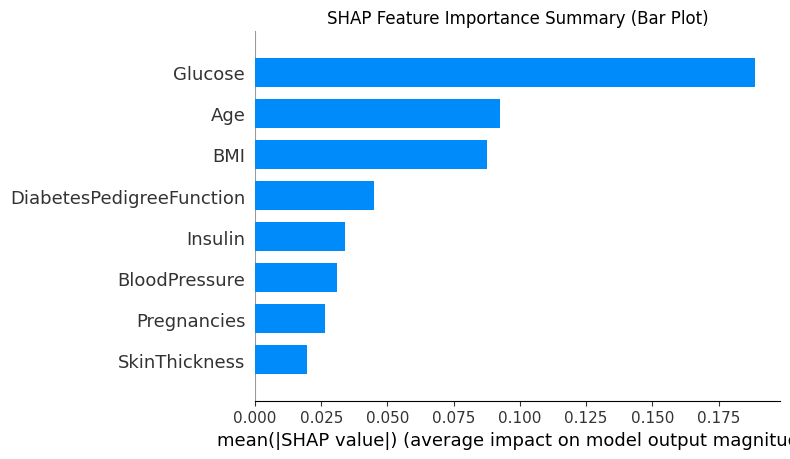

/tmp/ipython-input-124196340.py:17: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_subset_df, show=False)


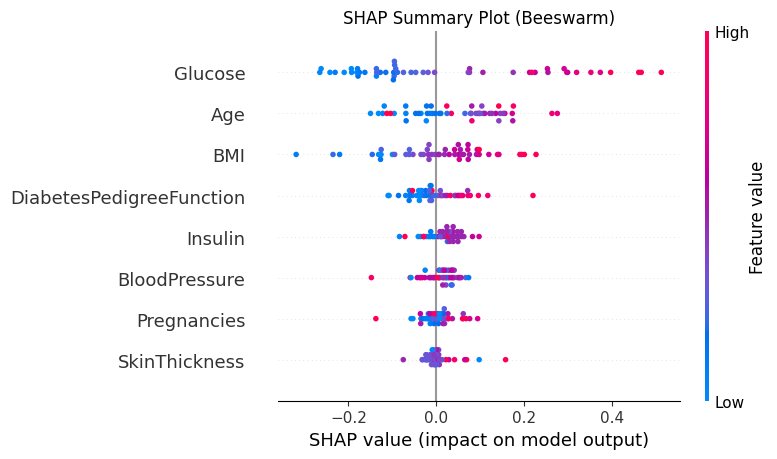

SHAP summary plots displayed.


In [ ]:
import matplotlib.pyplot as plt

# The explainer for GradientExplainer for a single output Keras model
# typically returns shap_values_subset with shape (num_samples, num_features, 1).
# We need to squeeze the last dimension to get (num_samples, num_features).
shap_values = shap_values_subset.squeeze()

# Ensure X_test_subset has feature names for better visualization
X_test_subset_df = pd.DataFrame(X_test[:50], columns=X.columns)

print("Generating SHAP summary plot...")
shap.summary_plot(shap_values, X_test_subset_df, plot_type="bar", show=False)
plt.title('SHAP Feature Importance Summary (Bar Plot)')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_test_subset_df, show=False)
plt.title('SHAP Summary Plot (Beeswarm)')
plt.tight_layout()
plt.show()
print("SHAP summary plots displayed.")

**Reasoning**:
The `AttributeError` occurred because `shap.GradientExplainer` did not expose the `expected_value` attribute directly in the expected manner for `force_plot`. To fix this, I will manually calculate the `expected_value` (base value) by first obtaining the model's predictions (probabilities) on the background dataset (`X_train[:100]`), converting these probabilities to log-odds, and then taking their mean. This `expected_value` is compatible with the `shap_values` generated by `GradientExplainer` for binary classification, which typically explain contributions to the log-odds output.



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
Generating SHAP force plot for instance 0...


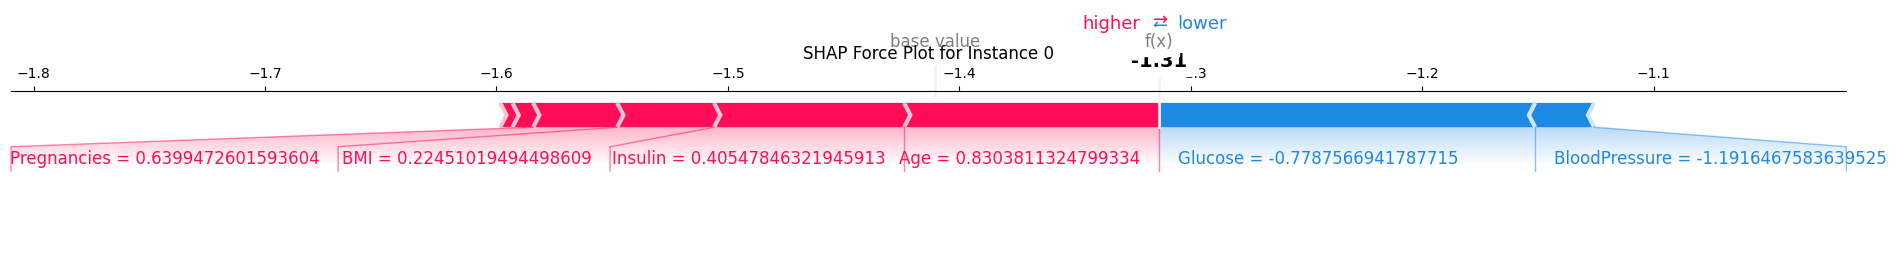

SHAP force plot for an individual prediction displayed.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate the expected value (base value) from the background data.
# For a Keras model with sigmoid output, model.predict gives probabilities.
# GradientExplainer typically explains contributions to the log-odds (logits) output.
# So, we convert the background probabilities to log-odds and take their mean.
background_probabilities = model.predict(X_train[:100]).flatten()

# Clip probabilities to avoid log(0) or log(1) issues in log-odds calculation
background_probabilities = np.clip(background_probabilities, 1e-7, 1 - 1e-7)
background_logits = np.log(background_probabilities / (1 - background_probabilities))

# The expected value is the mean of these background logits
expected_value = np.mean(background_logits)

# Visualize an individual prediction (e.g., the first instance in the subset)
instance_index = 0
shap_values_instance = shap_values[instance_index]
X_test_instance = X_test_subset_df.iloc[instance_index]

print(f"Generating SHAP force plot for instance {instance_index}...")
shap.force_plot(expected_value, shap_values_instance, X_test_instance, matplotlib=True, show=False)
plt.title(f'SHAP Force Plot for Instance {instance_index}')
plt.tight_layout()
plt.show()
print("SHAP force plot for an individual prediction displayed.")